In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import RMSprop
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Keep output clean by suppressing warnings

In [2]:
# Storing results for each cryptocurrency.
results = {}

# Define the cryptocurrencies being predicted
cryptocurrencies = {
    'Bitcoin': 'BTC-USD',
    'Ethereum': 'ETH-USD',
    'Dogecoin': 'DOGE-USD',
    'Bitcoin Cash': 'BCH-USD'
}


Analyzing Bitcoin to predict its closing price...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



Bitcoin Results:
  Linear Regression: MSE = 5993304.06, R² = 0.9264
  SVM: MSE = 1080905854.12, R² = -12.2828
  LSTM: MSE = 25049311.28, R² = 0.7033
  Ensemble (LR+LSTM): MSE = 6176400.30, R² = 0.9241


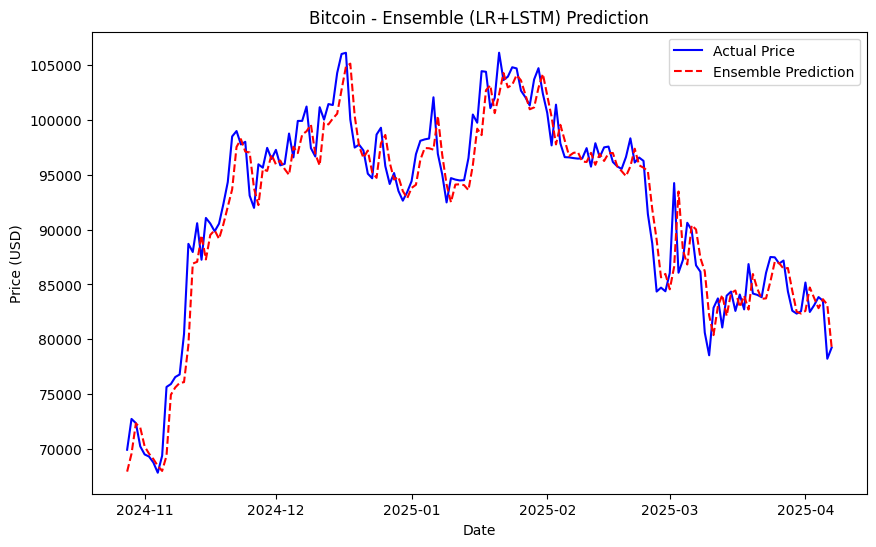


Analyzing Ethereum to predict its closing price...


[*********************100%***********************]  1 of 1 completed



Ethereum Results:
  Linear Regression: MSE = 13247.34, R² = 0.9684
  SVM: MSE = 469795.46, R² = -0.1222
  LSTM: MSE = 53842.63, R² = 0.8709
  Ensemble (LR+LSTM): MSE = 13540.17, R² = 0.9677


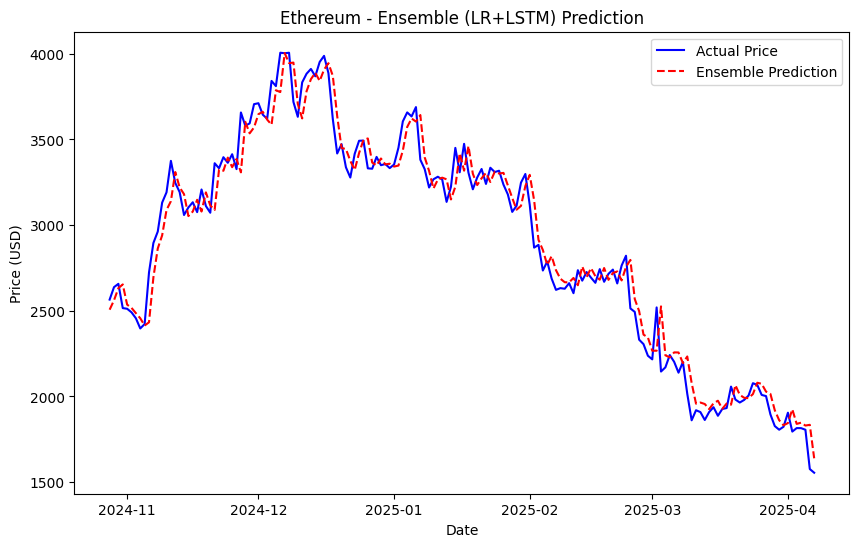


Analyzing Dogecoin to predict its closing price...


[*********************100%***********************]  1 of 1 completed



Dogecoin Results:
  Linear Regression: MSE = 0.00, R² = 0.9613
  SVM: MSE = 0.06, R² = -5.4824
  LSTM: MSE = 0.00, R² = 0.5317
  Ensemble (LR+LSTM): MSE = 0.00, R² = 0.9593


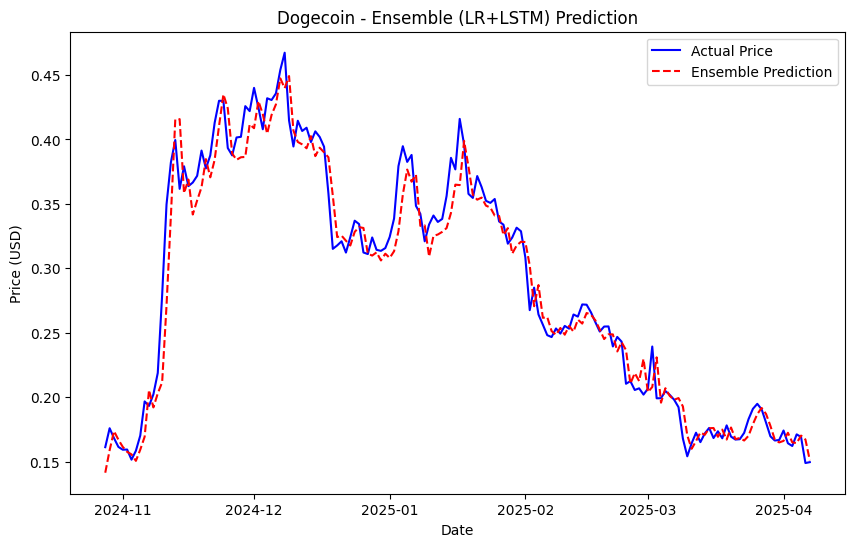


Analyzing Bitcoin Cash to predict its closing price...


[*********************100%***********************]  1 of 1 completed



Bitcoin Cash Results:
  Linear Regression: MSE = 425.42, R² = 0.9380
  SVM: MSE = 13631.40, R² = -0.9867
  LSTM: MSE = 2058.17, R² = 0.6990
  Ensemble (LR+LSTM): MSE = 420.29, R² = 0.9387


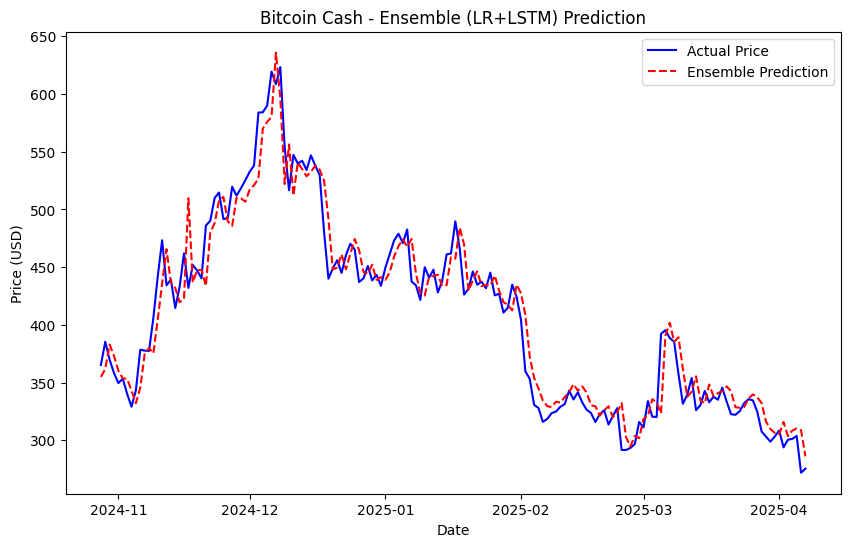

In [3]:
for crypto_name, ticker in cryptocurrencies.items():
    print(f"\nAnalyzing {crypto_name} to predict its closing price...")

    # Fetch Historical Data
    data = yf.download(ticker, start='2023-01-01', end='2025-04-08', interval='1d')
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]  # Key price and volume data
    data['DateNumber'] = pd.to_datetime(data.index).map(lambda date: date.toordinal())  # Numeric dates

    # Adding Useful Features 
    # Lagged closing prices
    data['Yesterday_Close'] = data['Close'].shift(1)
    data['Two_Days_Ago_Close'] = data['Close'].shift(2)
    data['Three_Days_Ago_Close'] = data['Close'].shift(3)
    
    # Moving averages for trends
    data['Five_Day_Avg'] = data['Close'].rolling(window=5).mean()
    data['Ten_Day_EMA'] = data['Close'].ewm(span=10, adjust=False).mean()
    
    # RSI for momentum
    price_change = data['Close'].diff()
    gains = price_change.where(price_change > 0, 0)
    losses = (-price_change).where(price_change < 0, 0)
    avg_gain = gains.rolling(window=14, min_periods=1).mean()
    avg_loss = losses.rolling(window=14, min_periods=1).mean()
    rs = avg_gain / (avg_loss + 1e-10)  # to avoid division by zero
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # Volatility and volume metrics
    data['Daily_Volatility'] = data['High'] - data['Low']
    data['Volume_Change'] = data['Volume'].pct_change().fillna(0)
    data['Price_Change'] = data['Close'].diff().fillna(0)
    
    # Bollinger Bands for price range
    data['BB_Middle'] = data['Close'].rolling(window=20).mean()
    data['BB_StdDev'] = data['Close'].rolling(window=20).std()
    data['BB_Upper'] = data['BB_Middle'] + 2 * data['BB_StdDev']
    data['BB_Lower'] = data['BB_Middle'] - 2 * data['BB_StdDev']

    X = data[['Open', 'High', 'Low', 'Volume', 'DateNumber', 'Yesterday_Close', 
              'Two_Days_Ago_Close', 'Three_Days_Ago_Close', 'Five_Day_Avg', 'Ten_Day_EMA', 
              'RSI', 'Daily_Volatility', 'Volume_Change', 'Price_Change', 
              'BB_Upper', 'BB_Lower']].shift(1).dropna()
    
    # y: Target closing price
    y = data['Close'][len(data) - len(X):]
    
    # Scaling
    X_scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = X_scaler.fit_transform(X)
    y_scaler = MinMaxScaler(feature_range=(0, 1))
    y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

    # Split: 80% train, 20% test 
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, 
                                                         test_size=0.2, shuffle=False)
    y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # LR Model 
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_predictions_scaled = lr.predict(X_test).flatten()
    lr_predictions = y_scaler.inverse_transform(lr_predictions_scaled.reshape(-1, 1)).flatten()
    lr_error = mean_squared_error(y_test_actual, lr_predictions)
    lr_accuracy = r2_score(y_test_actual, lr_predictions)

    # SVM model
    svm = SVR(kernel='rbf', C=1000, epsilon=0.01)  # Adjusted for better fit
    svm.fit(X_train, y_train)
    svm_predictions_scaled = svm.predict(X_test).flatten()
    svm_predictions = y_scaler.inverse_transform(svm_predictions_scaled.reshape(-1, 1)).flatten()
    svm_error = mean_squared_error(y_test_actual, svm_predictions)
    svm_accuracy = r2_score(y_test_actual, svm_predictions)

    # LSTM Model 
    # Prepare 15-day sequences
    closing_prices = data['Close'].values.reshape(-1, 1)
    lstm_scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_closing_prices = lstm_scaler.fit_transform(closing_prices)
    
    lookback_days = 15
    X_lstm, y_lstm = [], []
    for i in range(lookback_days, len(scaled_closing_prices)):
        X_lstm.append(scaled_closing_prices[i - lookback_days:i, 0])
        y_lstm.append(scaled_closing_prices[i, 0])
    X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)
    
    # Split LSTM data
    train_size = int(len(X_lstm) * 0.8)
    X_lstm_train = X_lstm[:train_size]
    y_lstm_train = y_lstm[:train_size]
    X_lstm_test = X_lstm[train_size:]
    y_lstm_test = y_lstm[train_size:]
    
    # Reshape for LSTM
    X_lstm_train = X_lstm_train.reshape((X_lstm_train.shape[0], X_lstm_train.shape[1], 1))
    X_lstm_test = X_lstm_test.reshape((X_lstm_test.shape[0], X_lstm_test.shape[1], 1))
    
    # Build LSTM
    lstm = Sequential()
    lstm.add(LSTM(250, input_shape=(lookback_days, 1), return_sequences=True))
    lstm.add(Dropout(0.2))  # Reducing overfitting
    lstm.add(LSTM(150, return_sequences=False))
    lstm.add(Dropout(0.2))
    lstm.add(Dense(50, activation='relu'))  # Refining predictions
    lstm.add(Dense(1))  # to output one price
    lstm.compile(optimizer=RMSprop(learning_rate=0.0001), loss=Huber())
    lstm.fit(X_lstm_train, y_lstm_train, epochs=150, batch_size=8, validation_split=0.2, 
             callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], 
             verbose=0)
    
    # LSTM predictions
    lstm_predictions_scaled = lstm.predict(X_lstm_test, verbose=0)
    lstm_predictions = lstm_scaler.inverse_transform(lstm_predictions_scaled).flatten()
    y_lstm_test_actual = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()
    lstm_error = mean_squared_error(y_lstm_test_actual, lstm_predictions)
    lstm_accuracy = r2_score(y_lstm_test_actual, lstm_predictions)

    # Ensemble (LR + LSTM) 
    # Align prediction lengths
    lr_test_size = len(lr_predictions)
    lstm_test_size = len(lstm_predictions)
    common_size = min(lr_test_size, lstm_test_size)
    
    lr_final_preds = lr_predictions[-common_size:]
    lstm_final_preds = lstm_predictions[-common_size:]
    actual_final_prices = y_test_actual[-common_size:]
    
    # Ensemble composition: 90% LR + 10% LSTM
    ensemble_predictions = 0.9 * lr_final_preds + 0.1 * lstm_final_preds
    ensemble_error = mean_squared_error(actual_final_prices, ensemble_predictions)
    ensemble_accuracy = r2_score(actual_final_prices, ensemble_predictions)

    # Storing and Displaying Results 
    results[crypto_name] = {
        'Linear Regression': {'MSE': lr_error, 'R2': lr_accuracy},
        'SVM': {'MSE': svm_error, 'R2': svm_accuracy},
        'LSTM': {'MSE': lstm_error, 'R2': lstm_accuracy},
        'Ensemble (LR+LSTM)': {'MSE': ensemble_error, 'R2': ensemble_accuracy}
    }
    
    print(f"\n{crypto_name} Results:")
    print(f"  Linear Regression: MSE = {lr_error:.2f}, R² = {lr_accuracy:.4f}")
    print(f"  SVM: MSE = {svm_error:.2f}, R² = {svm_accuracy:.4f}")
    print(f"  LSTM: MSE = {lstm_error:.2f}, R² = {lstm_accuracy:.4f}")
    print(f"  Ensemble (LR+LSTM): MSE = {ensemble_error:.2f}, R² = {ensemble_accuracy:.4f}")
    
    # Plot ensemble predictions
    test_dates = data.index[-len(y):][-common_size:]
    plt.figure(figsize=(10, 6))
    plt.plot(test_dates, actual_final_prices, label='Actual Price', color='blue')
    plt.plot(test_dates, ensemble_predictions, label='Ensemble Prediction', color='red', linestyle='--')
    plt.title(f'{crypto_name} - Ensemble (LR+LSTM) Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

In [4]:
print("\nSummary:")
for crypto_name in results.keys():
    print(f"\n{crypto_name}:")
    for model, metrics in results[crypto_name].items():
        print(f"  {model}: MSE = {metrics['MSE']:.2f}, R² = {metrics['R2']:.4f}")


Summary:

Bitcoin:
  Linear Regression: MSE = 5993304.06, R² = 0.9264
  SVM: MSE = 1080905854.12, R² = -12.2828
  LSTM: MSE = 25049311.28, R² = 0.7033
  Ensemble (LR+LSTM): MSE = 6176400.30, R² = 0.9241

Ethereum:
  Linear Regression: MSE = 13247.34, R² = 0.9684
  SVM: MSE = 469795.46, R² = -0.1222
  LSTM: MSE = 53842.63, R² = 0.8709
  Ensemble (LR+LSTM): MSE = 13540.17, R² = 0.9677

Dogecoin:
  Linear Regression: MSE = 0.00, R² = 0.9613
  SVM: MSE = 0.06, R² = -5.4824
  LSTM: MSE = 0.00, R² = 0.5317
  Ensemble (LR+LSTM): MSE = 0.00, R² = 0.9593

Bitcoin Cash:
  Linear Regression: MSE = 425.42, R² = 0.9380
  SVM: MSE = 13631.40, R² = -0.9867
  LSTM: MSE = 2058.17, R² = 0.6990
  Ensemble (LR+LSTM): MSE = 420.29, R² = 0.9387
